# 02_speech_analysis

speech_features_by_player: (11472, 16)
speech_features_by_game: (1434, 9)

Average number of messages by survival status:
alive_end
True     4.559606
False    2.680821
Name: n_messages, dtype: float64

Average number of messages by role:
role
Werewolf    3.916667
Villager    3.494247
Doctor      3.407950
Seer        3.020223
Name: n_messages, dtype: float64

Average message length by role:
role
Werewolf    558.638462
Villager    473.410219
Doctor      441.800459
Seer        408.815016
Name: avg_text_len, dtype: float64

Average first-day messages by survival status:
alive_end
True     1.996142
False    1.618480
Name: first_day_messages, dtype: float64

Average number of messages by winning team:
winner_team
Villagers     3.577375
Werewolves    3.420219
Name: n_messages, dtype: float64


/var/folders/n5/zt0gjw0s5sb_vp0j2jvg71s80000gn/T/ipykernel_11747/2797543520.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


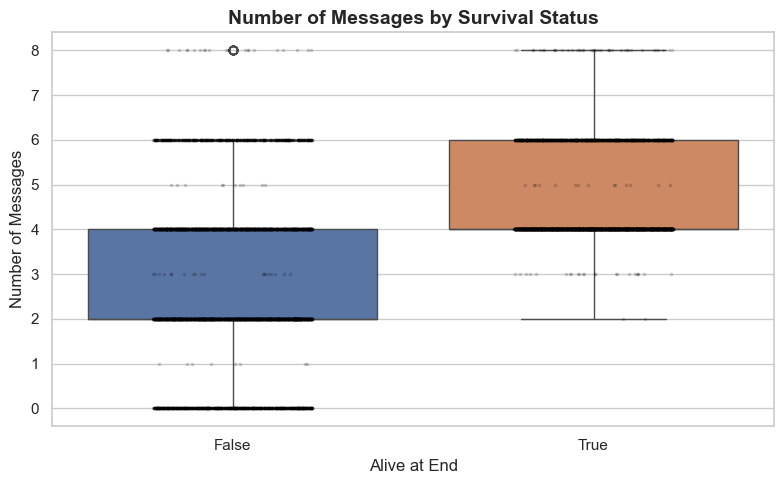

/var/folders/n5/zt0gjw0s5sb_vp0j2jvg71s80000gn/T/ipykernel_11747/2797543520.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


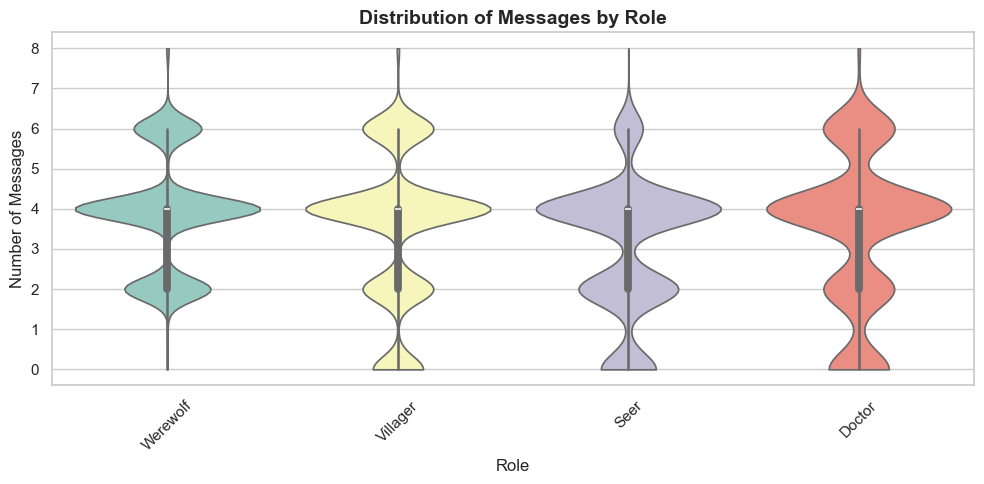

/var/folders/n5/zt0gjw0s5sb_vp0j2jvg71s80000gn/T/ipykernel_11747/2797543520.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


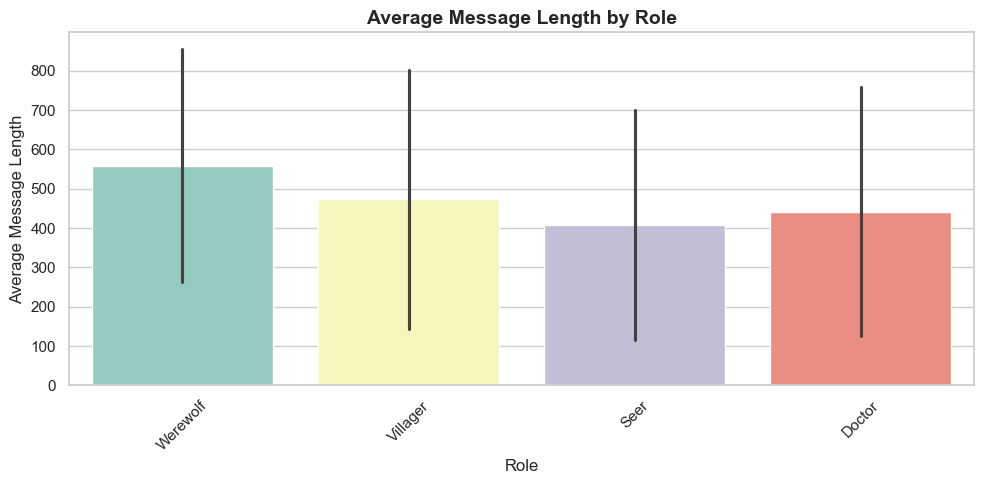

/var/folders/n5/zt0gjw0s5sb_vp0j2jvg71s80000gn/T/ipykernel_11747/2797543520.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


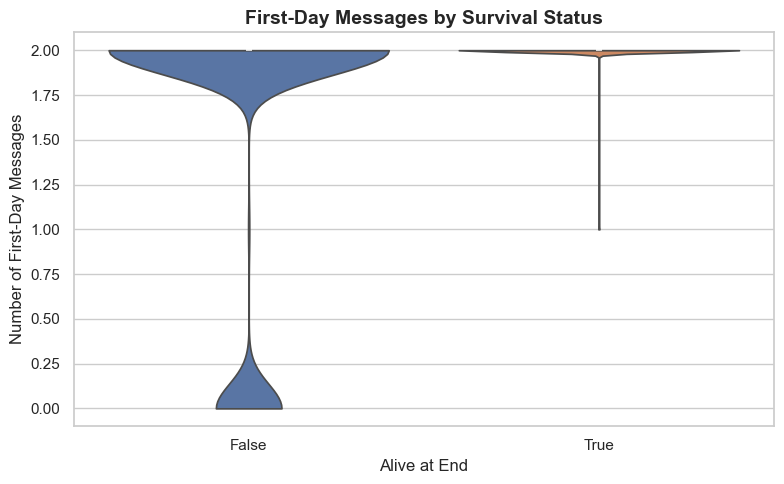

/var/folders/n5/zt0gjw0s5sb_vp0j2jvg71s80000gn/T/ipykernel_11747/2797543520.py:177: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


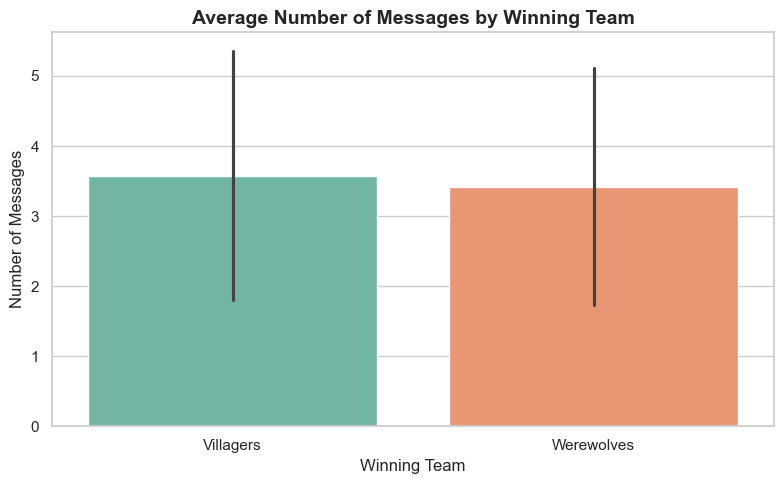

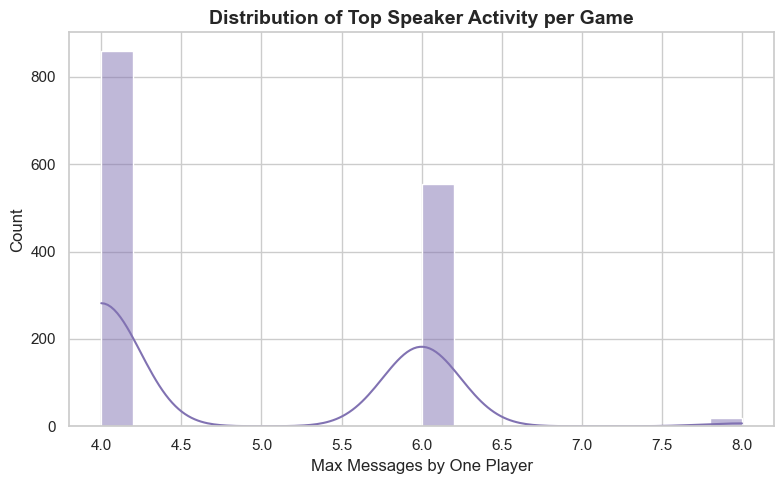

KeyError: 'n_day_messages'

In [7]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Route setting
base_dir = "/Users/wangtong/Desktop/26 Spring/STAT 605/group_project"
input_dir = os.path.join(base_dir, "analysis/speech_analysis/outputs")
plot_dir = os.path.join(base_dir, "analysis/speech_analysis/plots")

os.makedirs(plot_dir, exist_ok=True)


# Read data
speech_features_by_player = pd.read_csv(os.path.join(input_dir, "speech_features_by_player.csv"))
speech_features_by_game = pd.read_csv(os.path.join(input_dir, "speech_features_by_game.csv"))

print("speech_features_by_player:", speech_features_by_player.shape)
print("speech_features_by_game:", speech_features_by_game.shape)


# Summary
print("\nAverage number of messages by survival status:")
print(
    speech_features_by_player.groupby("alive_end")["n_messages"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage number of messages by role:")
print(
    speech_features_by_player.groupby("role")["n_messages"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage message length by role:")
print(
    speech_features_by_player.groupby("role")["avg_text_len"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage first-day messages by survival status:")
print(
    speech_features_by_player.groupby("alive_end")["first_day_messages"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage number of messages by winning team:")
print(
    speech_features_by_player.groupby("winner_team")["n_messages"]
    .mean()
    .sort_values(ascending=False)
)


sns.set_theme(style="whitegrid")

palette_binary = ["#4C72B0", "#DD8452"]
palette_role = ["#8DD3C7", "#FFFFB3", "#BEBADA", "#FB8072"]
palette_team = ["#66C2A5", "#FC8D62"]


# Figure 1: Number of speeches vs. Survival
# boxplot + stripplot
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=speech_features_by_player,
    x="alive_end",
    y="n_messages",
    palette=palette_binary
)
sns.stripplot(
    data=speech_features_by_player,
    x="alive_end",
    y="n_messages",
    color="black",
    alpha=0.18,
    jitter=0.22,
    size=2.5
)
plt.title("Number of Messages by Survival Status", fontsize=14, weight="bold")
plt.xlabel("Alive at End")
plt.ylabel("Number of Messages")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "01_messages_vs_survival.png"), dpi=300)
plt.show()


# Figure 2: Number of Speeches vs. Role
# violinplot
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=speech_features_by_player,
    x="role",
    y="n_messages",
    palette=palette_role,
    cut=0
)
plt.title("Distribution of Messages by Role", fontsize=14, weight="bold")
plt.xlabel("Role")
plt.ylabel("Number of Messages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "02_messages_by_role.png"), dpi=300)
plt.show()


# Figure 3: Average Speech Length vs. Role
# barplot
plt.figure(figsize=(10, 5))
sns.barplot(
    data=speech_features_by_player,
    x="role",
    y="avg_text_len",
    palette=palette_role,
    errorbar="sd"
)
plt.title("Average Message Length by Role", fontsize=14, weight="bold")
plt.xlabel("Role")
plt.ylabel("Average Message Length")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "03_avg_message_length_by_role.png"), dpi=300)
plt.show()


# Figure 4: Number of Speeches on the First Day vs. Survival
# violinplot
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=speech_features_by_player,
    x="alive_end",
    y="first_day_messages",
    palette=palette_binary,
    cut=0
)
plt.title("First-Day Messages by Survival Status", fontsize=14, weight="bold")
plt.xlabel("Alive at End")
plt.ylabel("Number of First-Day Messages")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "04_first_day_messages_vs_survival.png"), dpi=300)
plt.show()


# Figure 5: Number of Speeches vs. Win/Loss
# barplot
plt.figure(figsize=(8, 5))
sns.barplot(
    data=speech_features_by_player,
    x="winner_team",
    y="n_messages",
    palette=palette_team,
    errorbar="sd"
)
plt.title("Average Number of Messages by Winning Team", fontsize=14, weight="bold")
plt.xlabel("Winning Team")
plt.ylabel("Number of Messages")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "05_messages_by_winning_team.png"), dpi=300)
plt.show()


# Figure 6: Distribution of the number of comments made by the most active players in each round
# hist + kde
plt.figure(figsize=(8, 5))
sns.histplot(
    speech_features_by_game["max_messages_one_player"],
    bins=20,
    kde=True,
    color="#8172B2"
)
plt.title("Distribution of Top Speaker Activity per Game", fontsize=14, weight="bold")
plt.xlabel("Max Messages by One Player")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "06_top_speaker_distribution.png"), dpi=300)
plt.show()


# Figure 7: Daytime vs. Nighttime Speech Volume
# barplot（player-level均值）
phase_summary = pd.DataFrame({
    "phase": ["Day", "Night"],
    "avg_messages": [
        speech_features_by_player["n_day_messages"].mean(),
        speech_features_by_player["n_night_messages"].mean()
    ]
})

plt.figure(figsize=(7, 5))
sns.barplot(
    data=phase_summary,
    x="phase",
    y="avg_messages",
    palette=["#5DA5DA", "#F17CB0"]
)
plt.title("Average Number of Messages: Day vs Night", fontsize=14, weight="bold")
plt.xlabel("Phase")
plt.ylabel("Average Messages per Player")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "07_day_vs_night_messages.png"), dpi=300)
plt.show()


# Save a summary table
summary = {
    "avg_messages_alive_false": speech_features_by_player.loc[
        speech_features_by_player["alive_end"] == False, "n_messages"
    ].mean(),
    "avg_messages_alive_true": speech_features_by_player.loc[
        speech_features_by_player["alive_end"] == True, "n_messages"
    ].mean(),
    "avg_first_day_alive_false": speech_features_by_player.loc[
        speech_features_by_player["alive_end"] == False, "first_day_messages"
    ].mean(),
    "avg_first_day_alive_true": speech_features_by_player.loc[
        speech_features_by_player["alive_end"] == True, "first_day_messages"
    ].mean(),
    "avg_top_speaker_messages": speech_features_by_game["max_messages_one_player"].mean()
}

pd.DataFrame([summary]).to_csv(
    os.path.join(plot_dir, "speech_summary_stats.csv"),
    index=False
)

print("\nDone. Plots saved to:")
print(plot_dir)